# Feature-set ablation & peak-channel jitter — reproducible figures

**Purpose.** Regenerate the signed-off ablation and peak±k jitter figures for packs `noITL6_107` (small human, 107 units) and `noITL6_1603` (large human, 1603 recorded units → 1472 feature-complete units scored) from the **data shipped in this bundle**, with full-pipeline LaTeX. Another person or LLM should be able to re-run this notebook on any machine and match the numbers.

**No machine-specific paths.** All paths are resolved relative to the bundle folder (the folder that contains this notebook, `data/` and `code/`). No drive letters or user-profile folders are required.

**Bundle layout**
```
nw_pipeline_bundle/
├── fig_ablation_peak_jitter_pipeline.ipynb   (this notebook)
├── README.md, MANIFEST_sha256.txt, requirements.txt
├── code/cell_figure_style.py                 (figure style: colours, fonts, despine)
├── data/eap/Patients_mean_EAP_small_human_107.npy    (108, 90, 21)  raw mean EAP; unit 36 dropped -> 107
├── data/eap/Patients_mean_EAP_large_human_1603.npy   (1603, 240, 21) raw mean EAP; 1472 feature-complete rows used
├── data/vivo/vivo_small_human_107.csv                (107 rows, z-scored Wei features + labels)
├── data/vivo/vivo_large_human_1603_merged.csv        (1603 rows, z-scored Wei features + labels)
├── data/models/EAP_models_normalized.csv             (3947 simulated models; ITL6 dropped -> 3928)
├── data/packs/noITL6_107/04_peak_jitter/{metrics_all.json, peak_shift_curves.csv}
├── data/packs/noITL6_1603/04_peak_jitter/{metrics_all.json, peak_shift_curves.csv}
└── nw_notebook_out/                                  (figures written here)
```

**Figures** are drawn from the pack `metrics_all.json` + `peak_shift_curves.csv`. The raw `.npy` mean-EAP arrays, vivo tables and models table are included so an auditor can verify the inputs (shape, unit drop, 1603→1472 row filter, SHA-256) — see the *Raw data audit* section.

**Locked features (10, amplitude $A$ dropped):**
`W, TPW, Rslope, REP, spread, diff_spread, W_below, W_above, PL_below, PL_above`

- **Single 4** = `W, TPW, Rslope, REP`
- **Multi 6** = the other six
- Ablation = stratified **5-fold** type accuracy on **3928** no-ITL6 sim models (ITL6 dropped from 3947)

**How to run**
1. Open this notebook from inside the bundle folder (Jupyter / VS Code start the kernel in the notebook's folder). If your launcher uses a different working directory, set the environment variable `NW_BUNDLE_ROOT` to the bundle folder.
2. Keep `RECOMPUTE = False`.
3. Run All. Figures land in `nw_notebook_out/` inside the bundle; the final cell must print `ALL CONSISTENCY CHECKS PASSED`.

In [1]:
# --- Config ---
from __future__ import annotations
import hashlib
import json
import os
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- Paths: everything is relative to the bundle folder (no absolute paths) ----
def find_bundle_root() -> Path:
    """Bundle root = folder holding data/packs and code/cell_figure_style.py.

    Order: $NW_BUNDLE_ROOT if set, else the current working directory and its parents
    (Jupyter/VS Code start the kernel in the notebook's own folder).
    """
    def is_bundle(p: Path) -> bool:
        return (p / "data" / "packs").is_dir() and (p / "code" / "cell_figure_style.py").is_file()

    env = os.environ.get("NW_BUNDLE_ROOT", "").strip()
    if env:
        p = Path(env).expanduser().resolve()
        if not is_bundle(p):
            raise FileNotFoundError(f"NW_BUNDLE_ROOT={env!r} is not an nw_pipeline_bundle folder")
        return p
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if is_bundle(cand):
            return cand
        if is_bundle(cand / "nw_pipeline_bundle"):
            return cand / "nw_pipeline_bundle"
    raise FileNotFoundError(
        "Could not locate the bundle (needs data/packs and code/cell_figure_style.py). "
        "Open the notebook from inside nw_pipeline_bundle or set NW_BUNDLE_ROOT."
    )


BUNDLE_ROOT = find_bundle_root()
DATA = BUNDLE_ROOT / "data"
PACK_ROOT = DATA / "packs"          # <pack>/04_peak_jitter/{metrics_all.json, peak_shift_curves.csv}
EAP_DIR = DATA / "eap"              # raw mean-EAP .npy (small + large human)
VIVO_DIR = DATA / "vivo"            # vivo feature/label tables
MODELS_CSV = DATA / "models" / "EAP_models_normalized.csv"
CODE_DIR = BUNDLE_ROOT / "code"     # cell_figure_style.py only
OUT_DIR = BUNDLE_ROOT / "nw_notebook_out"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def rel(p: Path) -> str:
    """Path relative to the bundle (for machine-independent printouts)."""
    try:
        return Path(p).resolve().relative_to(BUNDLE_ROOT).as_posix()
    except ValueError:
        return str(p)

PACKS = ("noITL6_107", "noITL6_1603")
RECOMPUTE = False  # True => re-runs the original analysis code (not needed for figures; see end)

ALGOS = ["RF", "GBT", "SVM"]
K_SITES = list(range(-5, 6))
LOCKED_10 = [
    "W", "TPW", "Rslope", "REP",
    "spread", "diff_spread", "W_below", "W_above", "PL_below", "PL_above",
]
SINGLE_4 = ["W", "TPW", "Rslope", "REP"]
MULTI_6 = ["spread", "diff_spread", "W_below", "W_above", "PL_below", "PL_above"]

# Expected ablation (from metrics_all.json; ~3 decimals for supervisor check)
EXPECT_ABLATION = {
    "RF":  {"all10": 0.821, "single4": 0.604, "multi6": 0.784},
    "GBT": {"all10": 0.823, "single4": 0.573, "multi6": 0.777},
    "SVM": {"all10": 0.673, "single4": 0.434, "multi6": 0.540},
}

sys.path.insert(0, str(CODE_DIR))
import cell_figure_style as cfs
cfs.apply_cell_style()
ALGO_COLORS = dict(cfs.ALGO_COLORS)  # RF=seagreen, GBT=dodgerblue, SVM=darkturquoise

assert "A" not in LOCKED_10
assert set(SINGLE_4) | set(MULTI_6) == set(LOCKED_10)
assert set(SINGLE_4) & set(MULTI_6) == set()
print("Config OK")
print("BUNDLE_ROOT found:", BUNDLE_ROOT.name)
print("OUT_DIR =", rel(OUT_DIR))
print("RECOMPUTE =", RECOMPUTE)
print("ALGO_COLORS =", ALGO_COLORS)


# ---- Shared check registry (summarised in the last cell) ----
results = []

def check(name, ok, detail=""):
    results.append((name, bool(ok), detail))
    status = "PASS" if ok else "FAIL"
    print(f"[{status}] {name}" + (f" — {detail}" if detail else ""))

Config OK
BUNDLE_ROOT found: nw_pipeline_bundle
OUT_DIR = nw_notebook_out
RECOMPUTE = False
ALGO_COLORS = {'RF': 'seagreen', 'SVM': 'darkturquoise', 'GBT': 'dodgerblue'}


## Pipeline mathematics (matches `common.py`, `sta_ttype_classifier`, `run_04` / `run_02` / `run_03` / `run_05`)

### Locked feature set
Amplitude $A$ is **never** used. The paper Fig. 3 human set is the locked 10:

$$
\mathcal{F}_{10}=\{W,\,TPW,\,R_{\mathrm{slope}},\,REP,\,\mathrm{spread},\,\mathrm{diff\_spread},\,W_{\mathrm{below}},\,W_{\mathrm{above}},\,PL_{\mathrm{below}},\,PL_{\mathrm{above}}\}
$$

$$
\mathcal{F}_{4}=\{W,\,TPW,\,R_{\mathrm{slope}},\,REP\},\qquad
\mathcal{F}_{6}=\mathcal{F}_{10}\setminus\mathcal{F}_{4}
$$

### Wei single-channel features (`_cal_eap_features` / `_cal_one_ch_features`)
On the peak channel (after high-pass), with spline-upsampled waveform $v(t)$:

- Negative peak time $t_{-}$, amplitude $A=|v(t_{-})|$ (used only internally; **not** a classifier feature).
- **Half-width** $W$: time between the two half-amplitude crossings at $-A/2$ around the trough.
- **Trough-to-peak width** $TPW = t_{+} - t_{-}$ (first positive peak after the trough).
- **Repolarization** $REP$: time from the positive peak to the half-descent of that peak.
- **Rising slope** $R_{\mathrm{slope}}$: OLS slope of $v(t)$ on $[t_{-},\,t_{-}+0.03\,\mathrm{ms}]$.

### Multi-channel features (`_cal_multi_ch_features`, window $\pm 100\,\mu\mathrm{m}$)
With channel distances $d_c$ relative to the (possibly shifted) peak channel:

- $\mathrm{spread}=\mathrm{spread}_{\mathrm{below}}+\mathrm{spread}_{\mathrm{above}}$ — spatial extents where amplitude stays above $12\%$ of peak-channel max (`_cal_spread2`).
- $\mathrm{diff\_spread}=\mathrm{spread}_{\mathrm{above}}-\mathrm{spread}_{\mathrm{below}}$.
- $W_{\mathrm{below}}, W_{\mathrm{above}}$: $1000\times$ OLS slopes of width vs distance below/above peak.
- $PL_{\mathrm{below}}, PL_{\mathrm{above}}$: $1000\times$ OLS slopes of trough latency vs distance below/above peak.

### Model $z$-scoring (StandardScaler fit on sim raw)
Raw Wei features on simulated models have column means $\mu_{\mathrm{sim}}$ and SDs $\sigma_{\mathrm{sim}}$ (ddof 0 in the peak±k path). Published vivo tables are already in that $z$-space:

$$
z = \frac{x - \mu_{\mathrm{sim}}}{\sigma_{\mathrm{sim}}}
$$

### Hierarchical primary → type classifiers
For each algorithm $a\in\{\mathrm{RF},\mathrm{GBT},\mathrm{SVM}\}$:

1. Train primary E/I classifier on sim features.
2. Within each primary class, train a type classifier.
3. At test time: predict primary, then type within that primary.

### Ablation (this notebook’s bar chart)
Stratified **5-fold** CV **type** accuracy on **3928** models (ITL6 removed from 3947), separately for feature sets $\mathcal{F}_{10}$, $\mathcal{F}_{4}$, $\mathcal{F}_{6}$.

### Peak±k geometry (`run_04_peak_jitter.py`)
Local peak index in the 21-channel neighborhood (center $=10$) is shifted by $k\in\{-5,\ldots,+5\}$ sites at $20\,\mu\mathrm{m}$ pitch. Wei features are re-extracted with `extract_wei_features` (`volt_scale=0.01`, $t=\mathrm{arange}(T)/30 - 0.6\,\mathrm{ms}$ for 90-sample stacks).

**Anchoring (critical):**
- At $k=0$: use the **published vivo $z$-scored** feature row.
- At $k\neq 0$:

$$
z_{k} = z_{\mathrm{vivo}} + \frac{\mathrm{extract}_{k} - \mathrm{extract}_{0}}{\sigma_{\mathrm{sim}}^{\mathrm{raw}}}
$$

Flip rates vs the $k=0$ prediction:

$$
\mathrm{type\_flip}(k)=\Pr\!\big(\hat y^{\mathrm{type}}(k)\neq\hat y^{\mathrm{type}}(0)\big),\qquad
\mathrm{ei\_flip}(k)=\Pr\!\big(\hat y^{\mathrm{E/I}}(k)\neq\hat y^{\mathrm{E/I}}(0)\big)
$$

Accuracy columns in the CSV use vivo ground-truth types when labeled (`type_acc_vs_vivo_label` / `type_acc_all10`, and `type_acc_single4_vs_vivo` for the single-4 subset).

### Cliff’s $\delta$ (`run_05_label_noise_pac.py`)
From Mann–Whitney $U$:

$$
\delta = \frac{2U}{n_x n_y} - 1
$$

(theta endpoint: ITL35+ITL46 vs ITL23 on MMR; gamma: VIP vs PVALB+LAMP5).

### Expected calibration error (`run_02_calibration.py`)
Confidence = max class probability; $B$ equal-width bins on $[0,1]$:

$$
\mathrm{ECE}=\sum_{b=1}^{B}\frac{|I_b|}{n}\,\big|\overline{\mathrm{acc}}_{I_b}-\overline{\mathrm{conf}}_{I_b}\big|
$$

### Domain shift (`run_03_domain_shift.py`)
Per feature: two-sample KS statistic and Wasserstein-1 distance (sim vs vivo). Density-ratio weights from a logistic domain classifier on pooled features:

$$
w(x)\propto\frac{p_{\mathrm{vivo}}(x)}{p_{\mathrm{sim}}(x)}\approx\frac{\hat p(y{=}1\mid x)}{1-\hat p(y{=}1\mid x)},
\quad w\leftarrow\mathrm{clip}(w,0.1,10)/\overline{w}
$$

### PCA (`make_03_pca_2d.py`)
Pool sim+vivo locked features → `StandardScaler` → PCA ($2$ or $3$ components). PC axes are unitless; explained-variance ratios annotate the axes.

---
**Figure regeneration below uses only pack `metrics_all.json` + `peak_shift_curves.csv`.**


In [2]:
# --- Load pack metrics + curves ---
data = {}
for pack in PACKS:
    pdir = PACK_ROOT / pack / "04_peak_jitter"
    metrics = json.loads((pdir / "metrics_all.json").read_text(encoding="utf-8"))
    curves = pd.read_csv(pdir / "peak_shift_curves.csv")
    data[pack] = {"dir": pdir, "metrics": metrics, "curves": curves}
    print("loaded", rel(pdir / "metrics_all.json"), "and", rel(pdir / "peak_shift_curves.csv"))

    print(f"\n=== {pack} ===")
    print("includes_A:", metrics["includes_A"])
    print("feature_cols:", metrics["feature_cols"])
    print("n_features:", metrics["n_features"])
    print("mean_eap_geometry:", metrics["mean_eap_geometry"])
    ab = metrics["ablation_type_accuracy"]
    rows = []
    for algo in ALGOS:
        rows.append({
            "algo": algo,
            "all10": ab[algo]["all10"],
            "single4": ab[algo]["single4"],
            "multi6": ab[algo]["multi6"],
        })
    tab = pd.DataFrame(rows)
    print(tab.to_string(index=False))

# Ablation must be identical across packs
ab107 = data["noITL6_107"]["metrics"]["ablation_type_accuracy"]
ab1603 = data["noITL6_1603"]["metrics"]["ablation_type_accuracy"]
assert ab107 == ab1603, "Ablation tables differ across packs — unexpected"
ABLATION = ab107

# Hard asserts (supervisor / LLM audit)
assert data["noITL6_107"]["metrics"]["includes_A"] is False
assert data["noITL6_1603"]["metrics"]["includes_A"] is False
assert data["noITL6_107"]["metrics"]["feature_cols"] == LOCKED_10
assert "A" not in data["noITL6_107"]["metrics"]["feature_cols"]

def _approx(a, b, tol=0.0015):
    return abs(float(a) - float(b)) <= tol

assert _approx(ABLATION["RF"]["all10"], 0.821)
assert _approx(ABLATION["GBT"]["all10"], 0.823)
assert _approx(ABLATION["SVM"]["all10"], 0.673)
print("\nLOAD ASSERTS: PASS")

loaded data/packs/noITL6_107/04_peak_jitter/metrics_all.json and data/packs/noITL6_107/04_peak_jitter/peak_shift_curves.csv

=== noITL6_107 ===
includes_A: False
feature_cols: ['W', 'TPW', 'Rslope', 'REP', 'spread', 'diff_spread', 'W_below', 'W_above', 'PL_below', 'PL_above']
n_features: 10
mean_eap_geometry: {'shape': [107, 90, 21], 'layout': '(n_units, n_time, n_channels)', 'center_channel': 10, 'pitch_um': 20.0, 'volt_scale': 0.01, 'bad_unit_dropped': 36, 'k_sites': [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]}
algo    all10  single4   multi6
  RF 0.820774 0.603615 0.784114
 GBT 0.823320 0.573320 0.776731
 SVM 0.672607 0.434063 0.540224
loaded data/packs/noITL6_1603/04_peak_jitter/metrics_all.json and data/packs/noITL6_1603/04_peak_jitter/peak_shift_curves.csv

=== noITL6_1603 ===
includes_A: False
feature_cols: ['W', 'TPW', 'Rslope', 'REP', 'spread', 'diff_spread', 'W_below', 'W_above', 'PL_below', 'PL_above']
n_features: 10
mean_eap_geometry: {'shape': [1472, 240, 21], 'layout': '(n_uni

In [3]:
# --- Figure: feature-set ablation (identical for both packs) ---
def plot_ablation(ablation, out_stem: Path):
    fig, ax = plt.subplots(figsize=(4.4, 3.3), constrained_layout=True)
    x = np.arange(3)
    width = 0.22
    keys = ["all10", "single4", "multi6"]
    for i, algo in enumerate(ALGOS):
        vals = [float(ablation[algo][k]) for k in keys]
        bars = ax.bar(
            x + (i - 1) * width, vals, width,
            label=algo, color=ALGO_COLORS[algo],
            edgecolor="black", linewidth=0.8, zorder=3,
        )
        for b, v in zip(bars, vals):
            ax.text(
                b.get_x() + b.get_width() / 2, v + 0.015,
                f"{v * 100:.1f}%", ha="center", va="bottom",
                fontsize=6.0, color="0.2",
            )
    ax.set_xticks(x)
    ax.set_xticklabels(["All 10", "Single 4", "Multi 6"])
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Type accuracy (5-fold, models)")
    ax.set_title("Feature-set ablation on models", loc="center")
    ax.legend(loc="upper right", fontsize=7)
    ax.axhline(0, color="0.7", lw=0.6, zorder=0)
    cfs.despine(ax)
    for ext in ("png", "pdf"):
        fig.savefig(out_stem.with_suffix("." + ext), dpi=400, pad_inches=0.35)
    plt.close(fig)
    return out_stem.with_suffix(".png")

ablation_png = plot_ablation(ABLATION, OUT_DIR / "fig_ablation")
print("WROTE", rel(ablation_png))

WROTE nw_notebook_out/fig_ablation.png


In [4]:
# --- Shared jitter helpers ---
def _ylim_with_pad(ax, y_values, pack: str, fixed_107: float = 0.01):
    """1603: ~4% of ymax below zero. 107: small fixed pad."""
    y = np.asarray(y_values, float)
    y = y[np.isfinite(y)]
    ymax = float(y.max()) if len(y) else 0.01
    ymax = max(ymax, 1e-6)
    if pack == "noITL6_1603":
        pad = 0.04 * ymax
    else:
        pad = float(fixed_107)
    ax.set_ylim(-pad, ymax * 1.18)


def plot_flip_curve(df, ycol, ylabel, pack, out_stem, title="Peak_channel jitter", fixed_107_pad=0.01):
    fig, ax = plt.subplots(figsize=(4.6, 3.3), constrained_layout=True)
    ys = []
    for algo in ALGOS:
        sub = df[df.algo == algo].sort_values("k_sites")
        ax.plot(
            sub.k_sites, sub[ycol], "o-",
            color=ALGO_COLORS[algo], label=algo, lw=1.6, markersize=4.5,
        )
        ys.append(sub[ycol].to_numpy(float))
    ax.set_xlabel("Peak shift (sites · 20 μm)")
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc="center")
    ax.set_xticks(K_SITES)
    _ylim_with_pad(ax, np.concatenate(ys), pack, fixed_107=fixed_107_pad)
    ax.axvline(0, color="0.75", lw=0.8, ls=":", zorder=0)
    ax.legend(loc="upper right", fontsize=7)
    cfs.despine(ax)
    for ext in ("png", "pdf"):
        fig.savefig(out_stem.with_suffix("." + ext), dpi=400, pad_inches=0.35)
    plt.close(fig)
    return out_stem.with_suffix(".png")

print("helpers OK")


helpers OK


In [5]:
# --- Type-flip figures ---
written = {}
for pack in PACKS:
    df = data[pack]["curves"]
    n_vivo = int(data[pack]["metrics"]["mean_eap_geometry"]["shape"][0])
    tag = "107" if pack.endswith("107") else "1603"
    # Note: signed-off title is exactly "Peak_channel jitter" (no n= in title)
    p = plot_flip_curve(
        df, "type_flip_vs_k0", "Type label flip rate vs k = 0",
        pack, OUT_DIR / f"fig_peak_jitter_type_flip_{tag}",
        title="Peak_channel jitter",
        fixed_107_pad=0.01,
    )
    written[f"type_flip_{tag}"] = p
    print("WROTE", rel(p), "| n_vivo=", n_vivo)

WROTE nw_notebook_out/fig_peak_jitter_type_flip_107.png | n_vivo= 107


WROTE nw_notebook_out/fig_peak_jitter_type_flip_1603.png | n_vivo= 1472


In [6]:
# --- E/I flip figures ---
for pack in PACKS:
    df = data[pack]["curves"]
    tag = "107" if pack.endswith("107") else "1603"
    p = plot_flip_curve(
        df, "ei_flip_vs_k0", "E/I label flip rate vs k = 0",
        pack, OUT_DIR / f"fig_peak_jitter_EI_flip_{tag}",
        title="Peak_channel jitter",
        fixed_107_pad=0.005,
    )
    written[f"ei_flip_{tag}"] = p
    print("WROTE", rel(p))

WROTE nw_notebook_out/fig_peak_jitter_EI_flip_107.png


WROTE nw_notebook_out/fig_peak_jitter_EI_flip_1603.png


**fig_ablation.png**  (`nw_notebook_out/fig_ablation.png`)

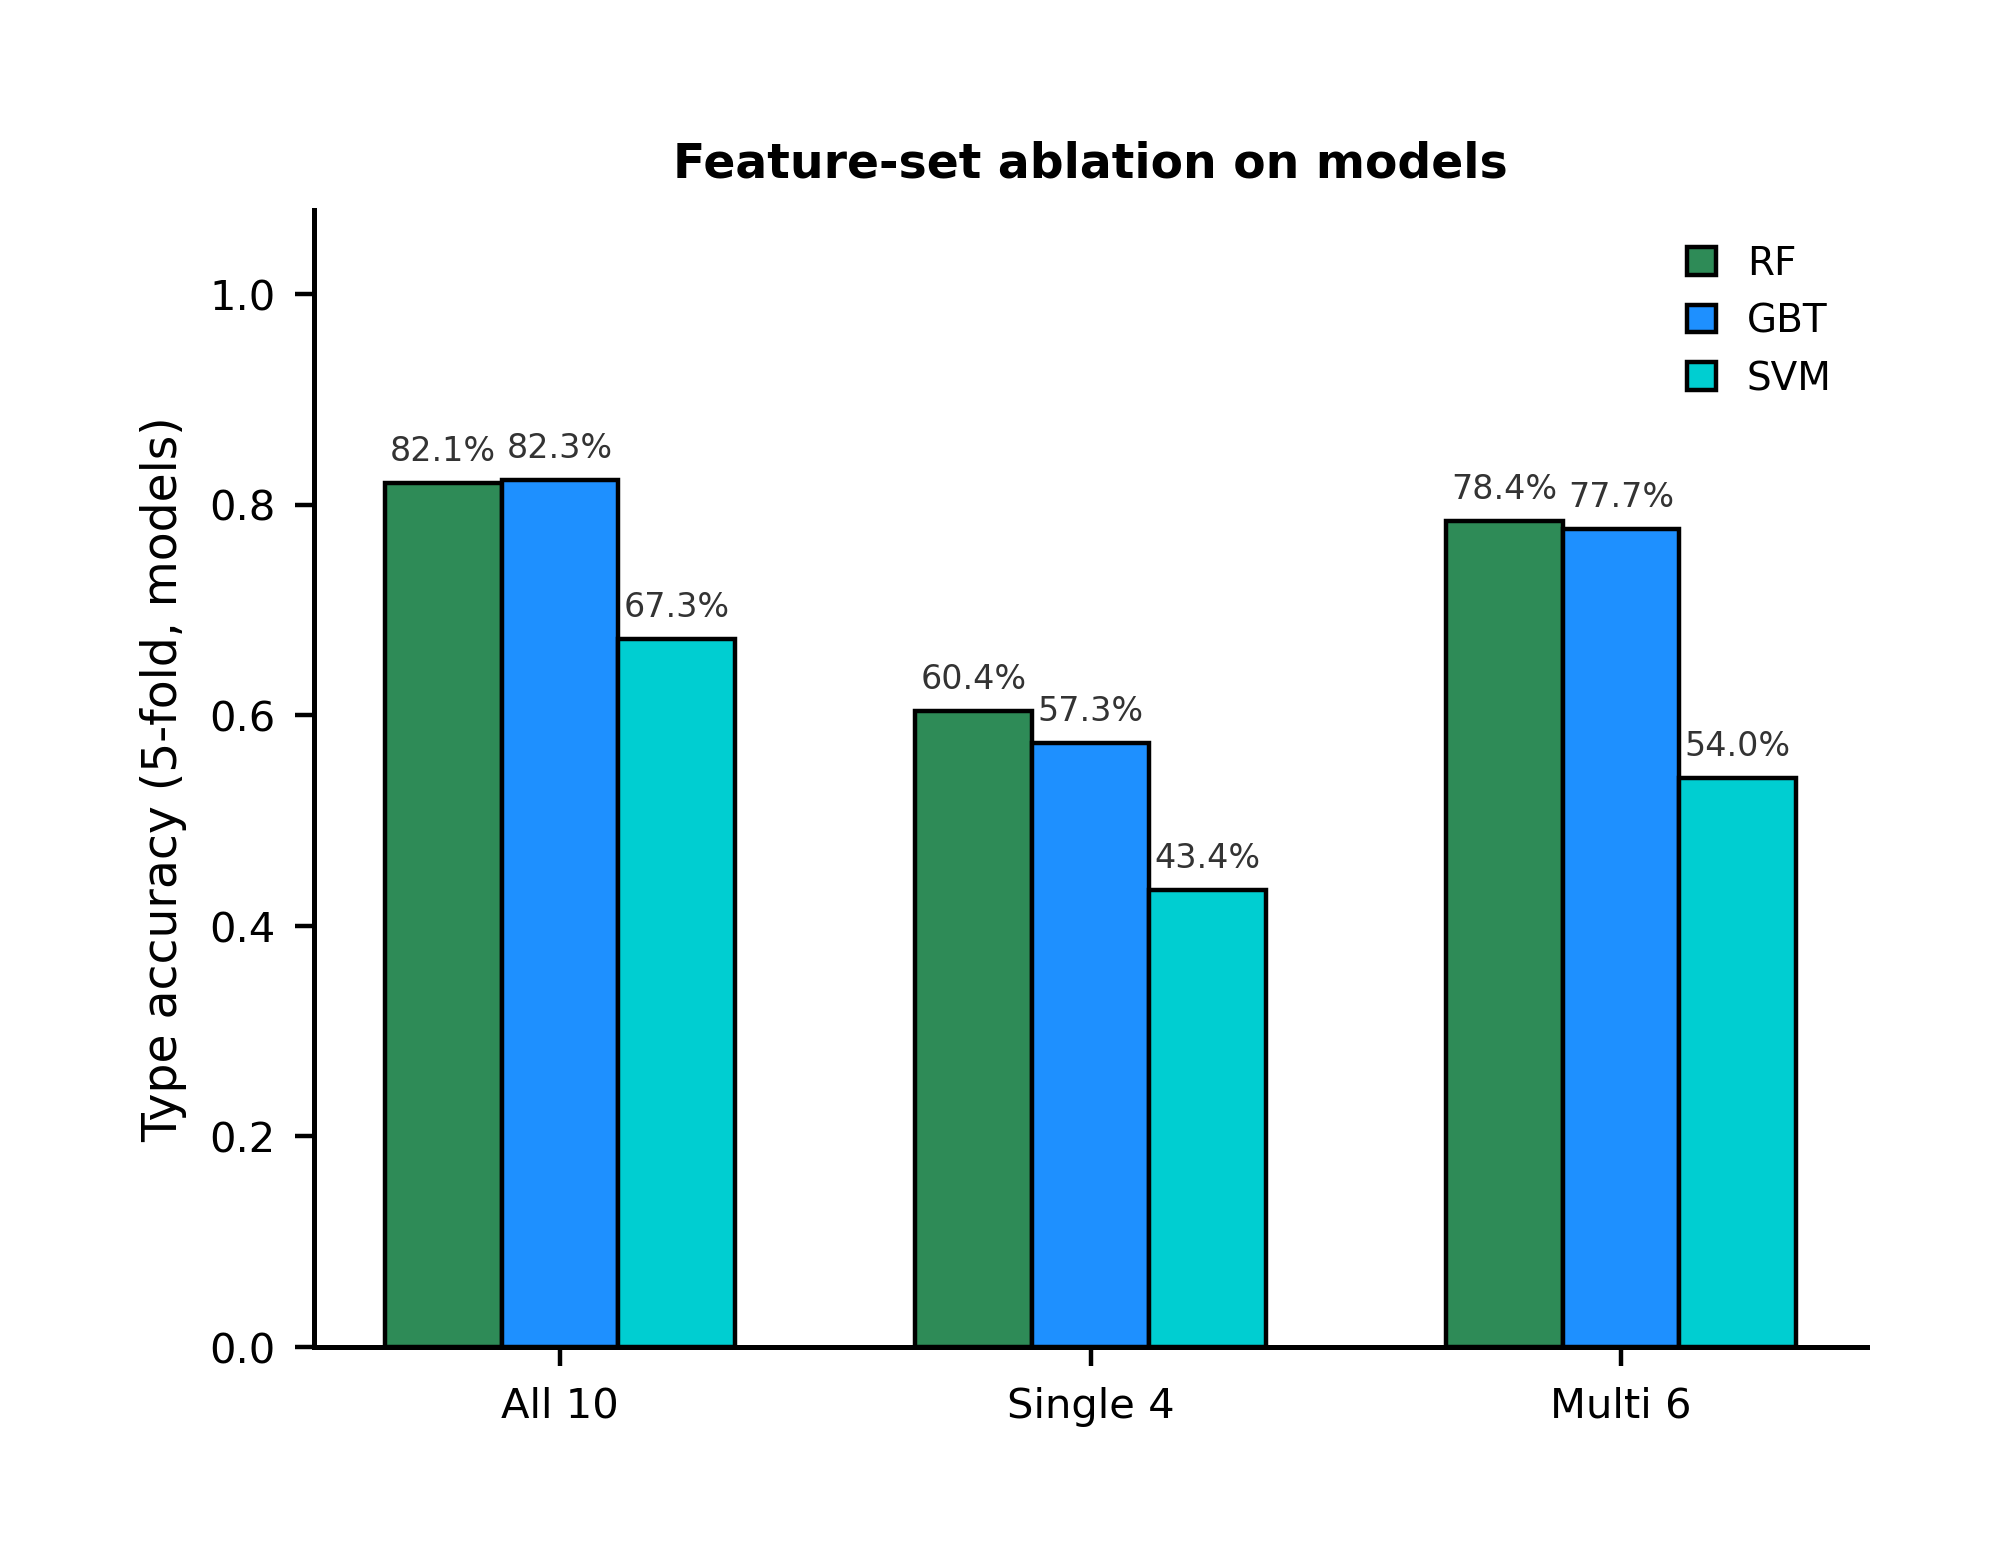

**fig_peak_jitter_type_flip_107.png**  (`nw_notebook_out/fig_peak_jitter_type_flip_107.png`)

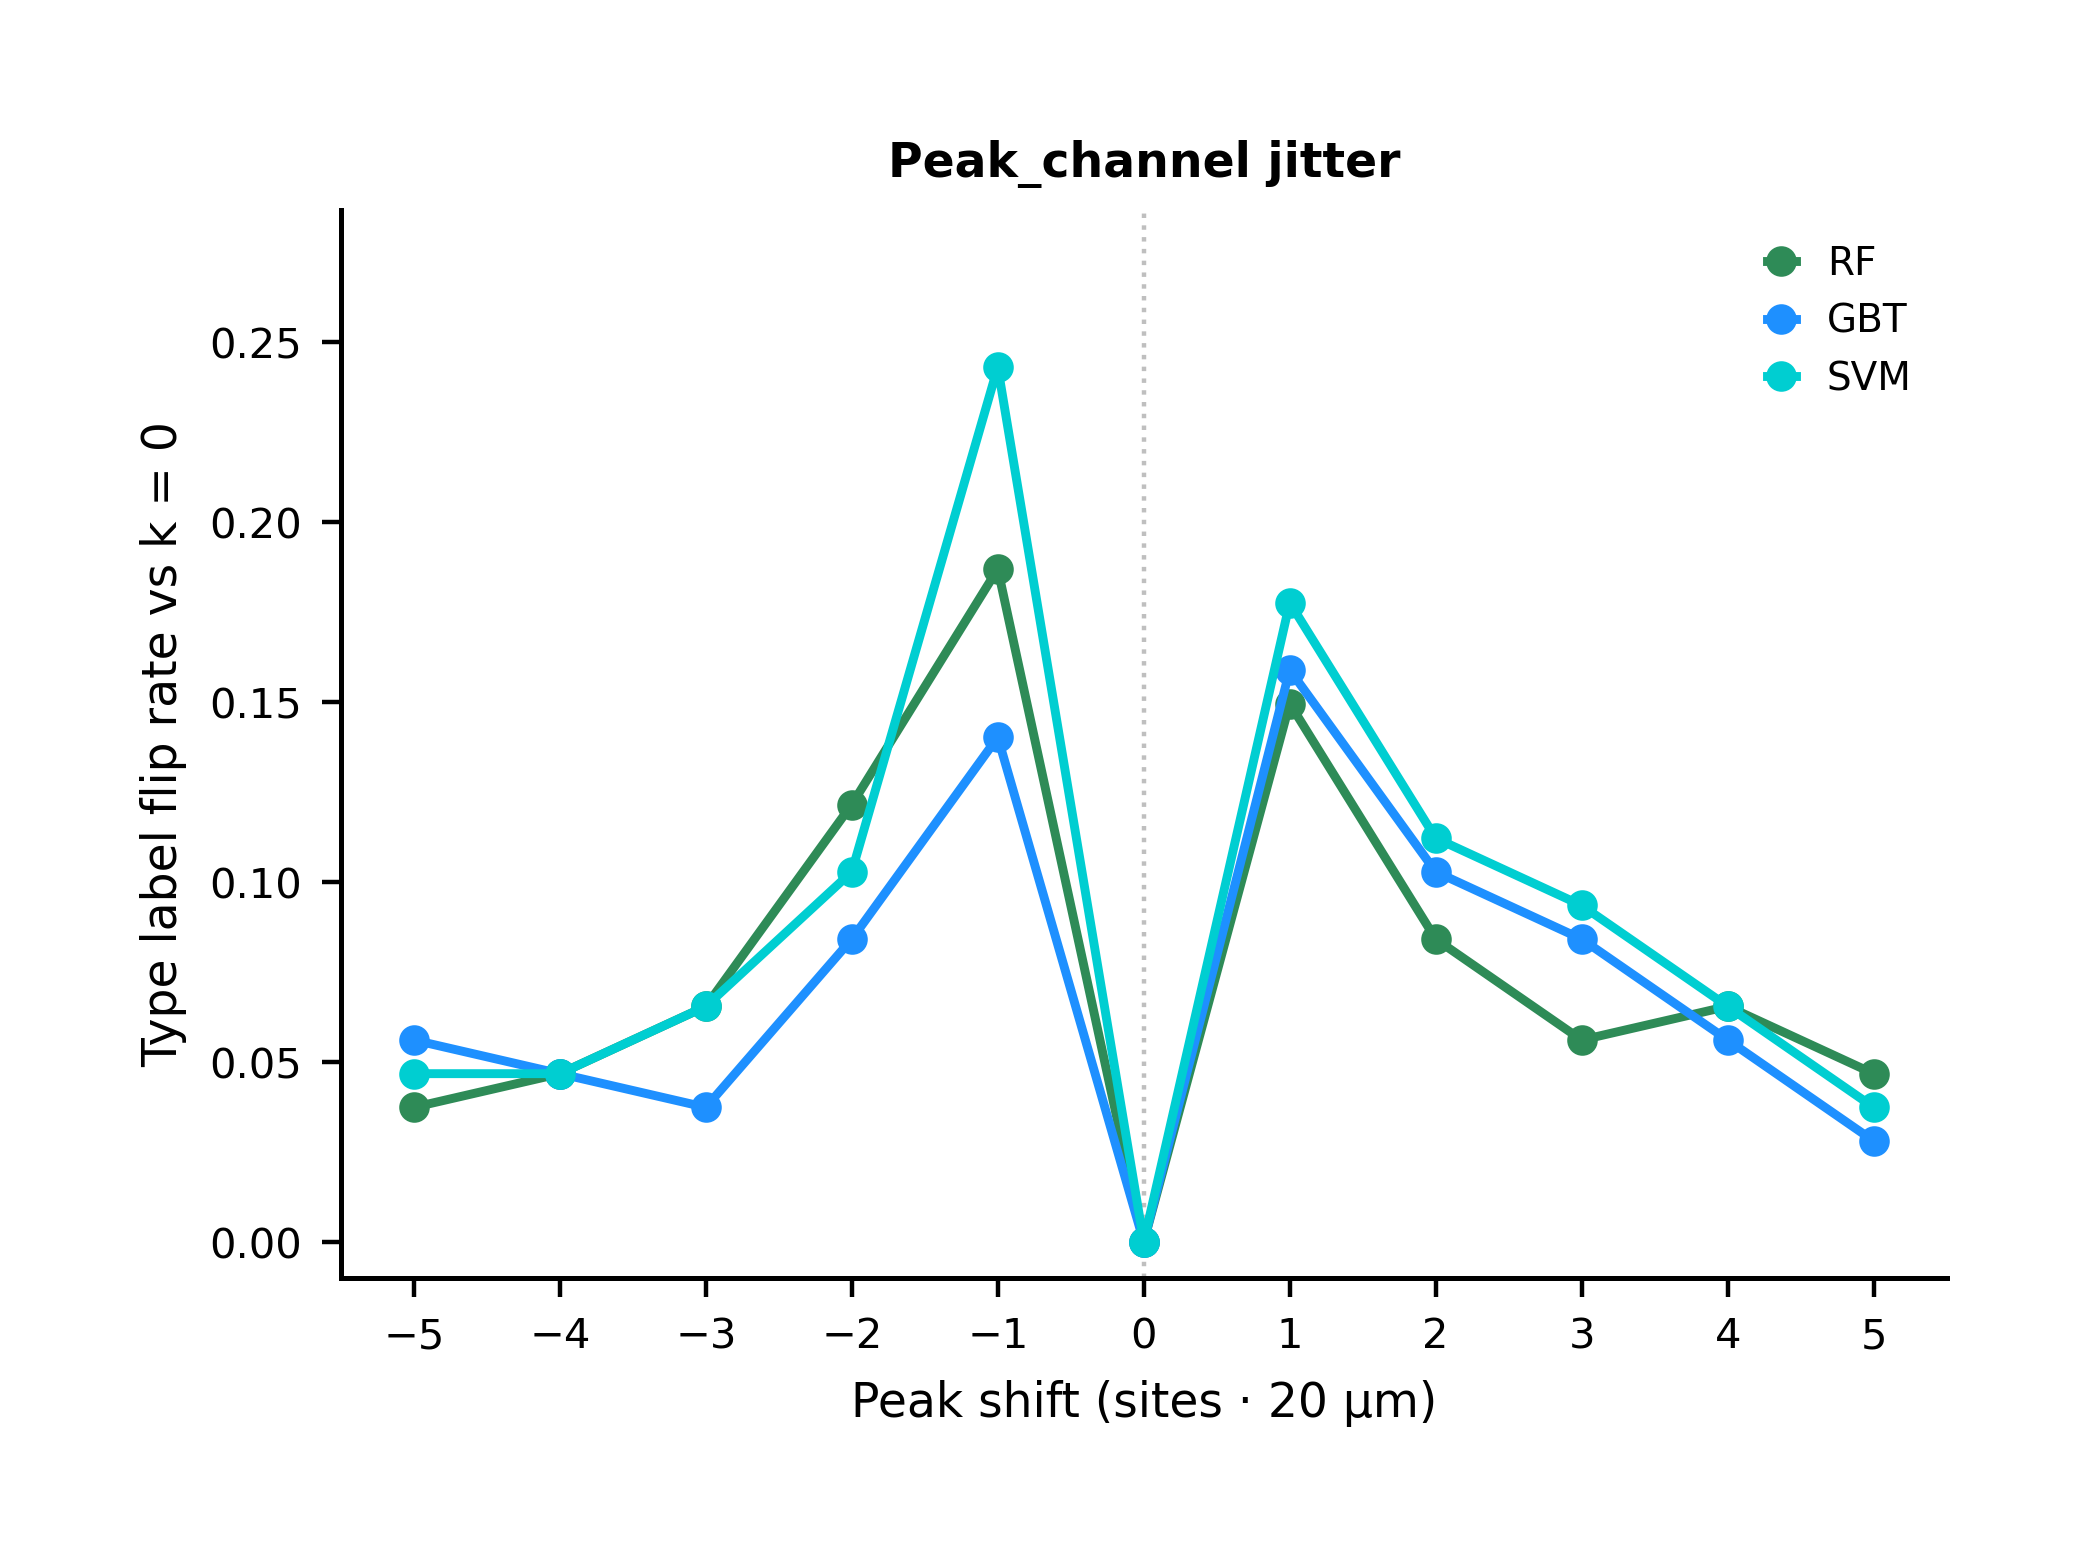

**fig_peak_jitter_type_flip_1603.png**  (`nw_notebook_out/fig_peak_jitter_type_flip_1603.png`)

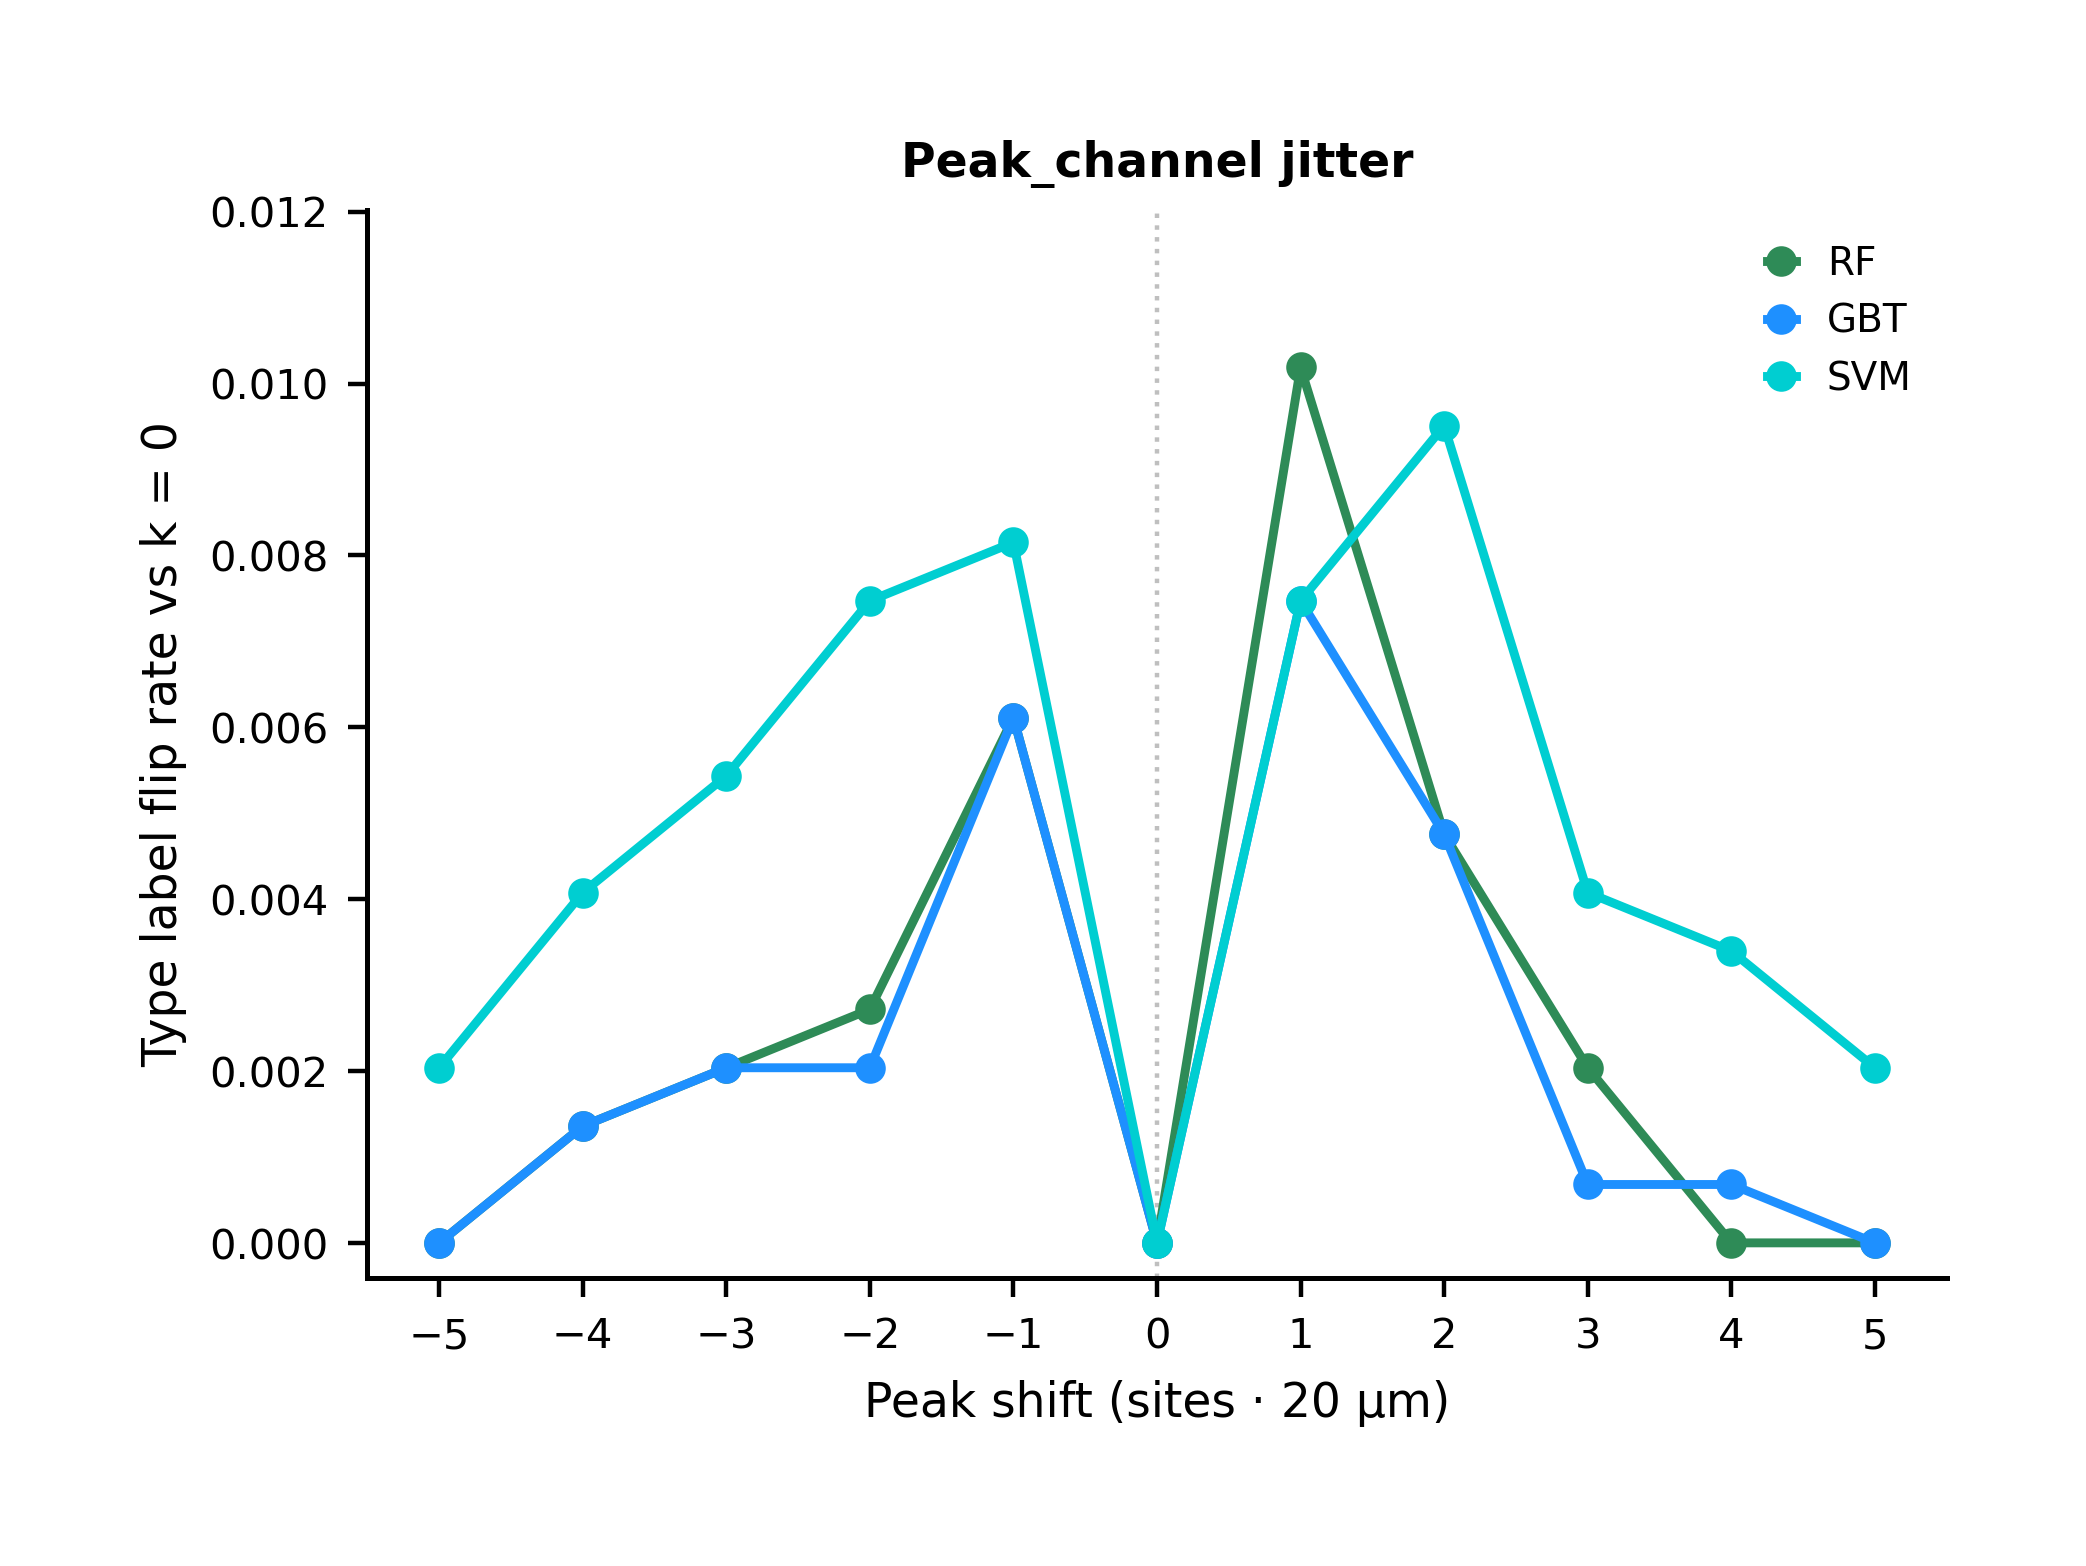

**fig_peak_jitter_EI_flip_107.png**  (`nw_notebook_out/fig_peak_jitter_EI_flip_107.png`)

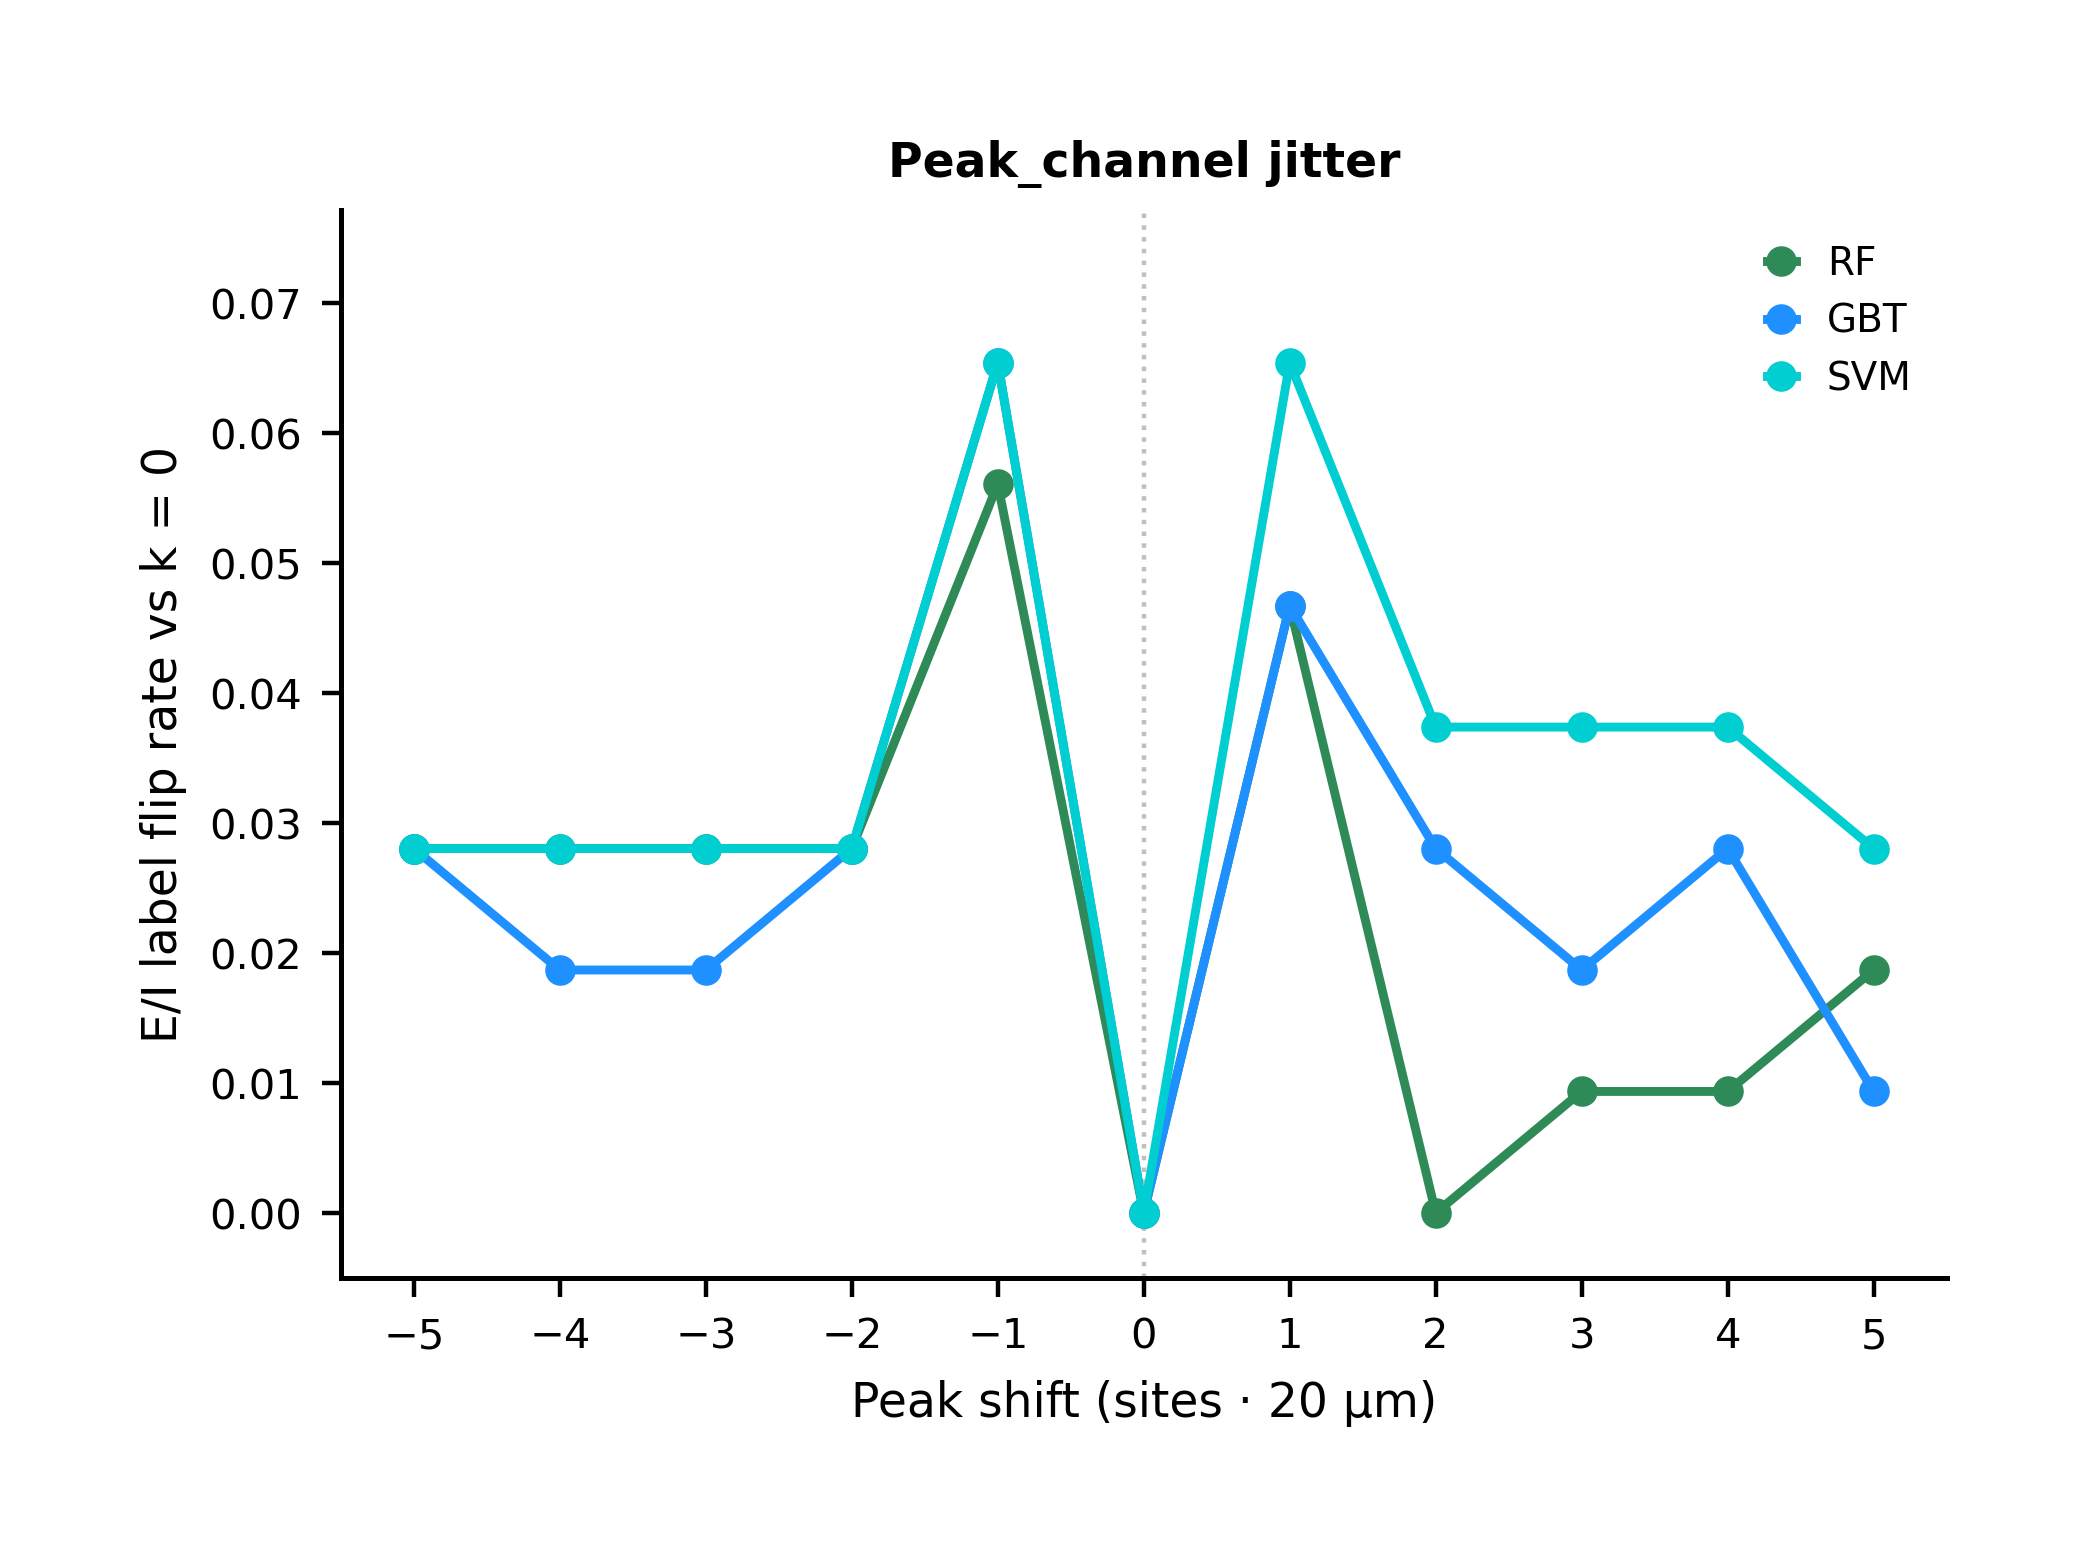

**fig_peak_jitter_EI_flip_1603.png**  (`nw_notebook_out/fig_peak_jitter_EI_flip_1603.png`)

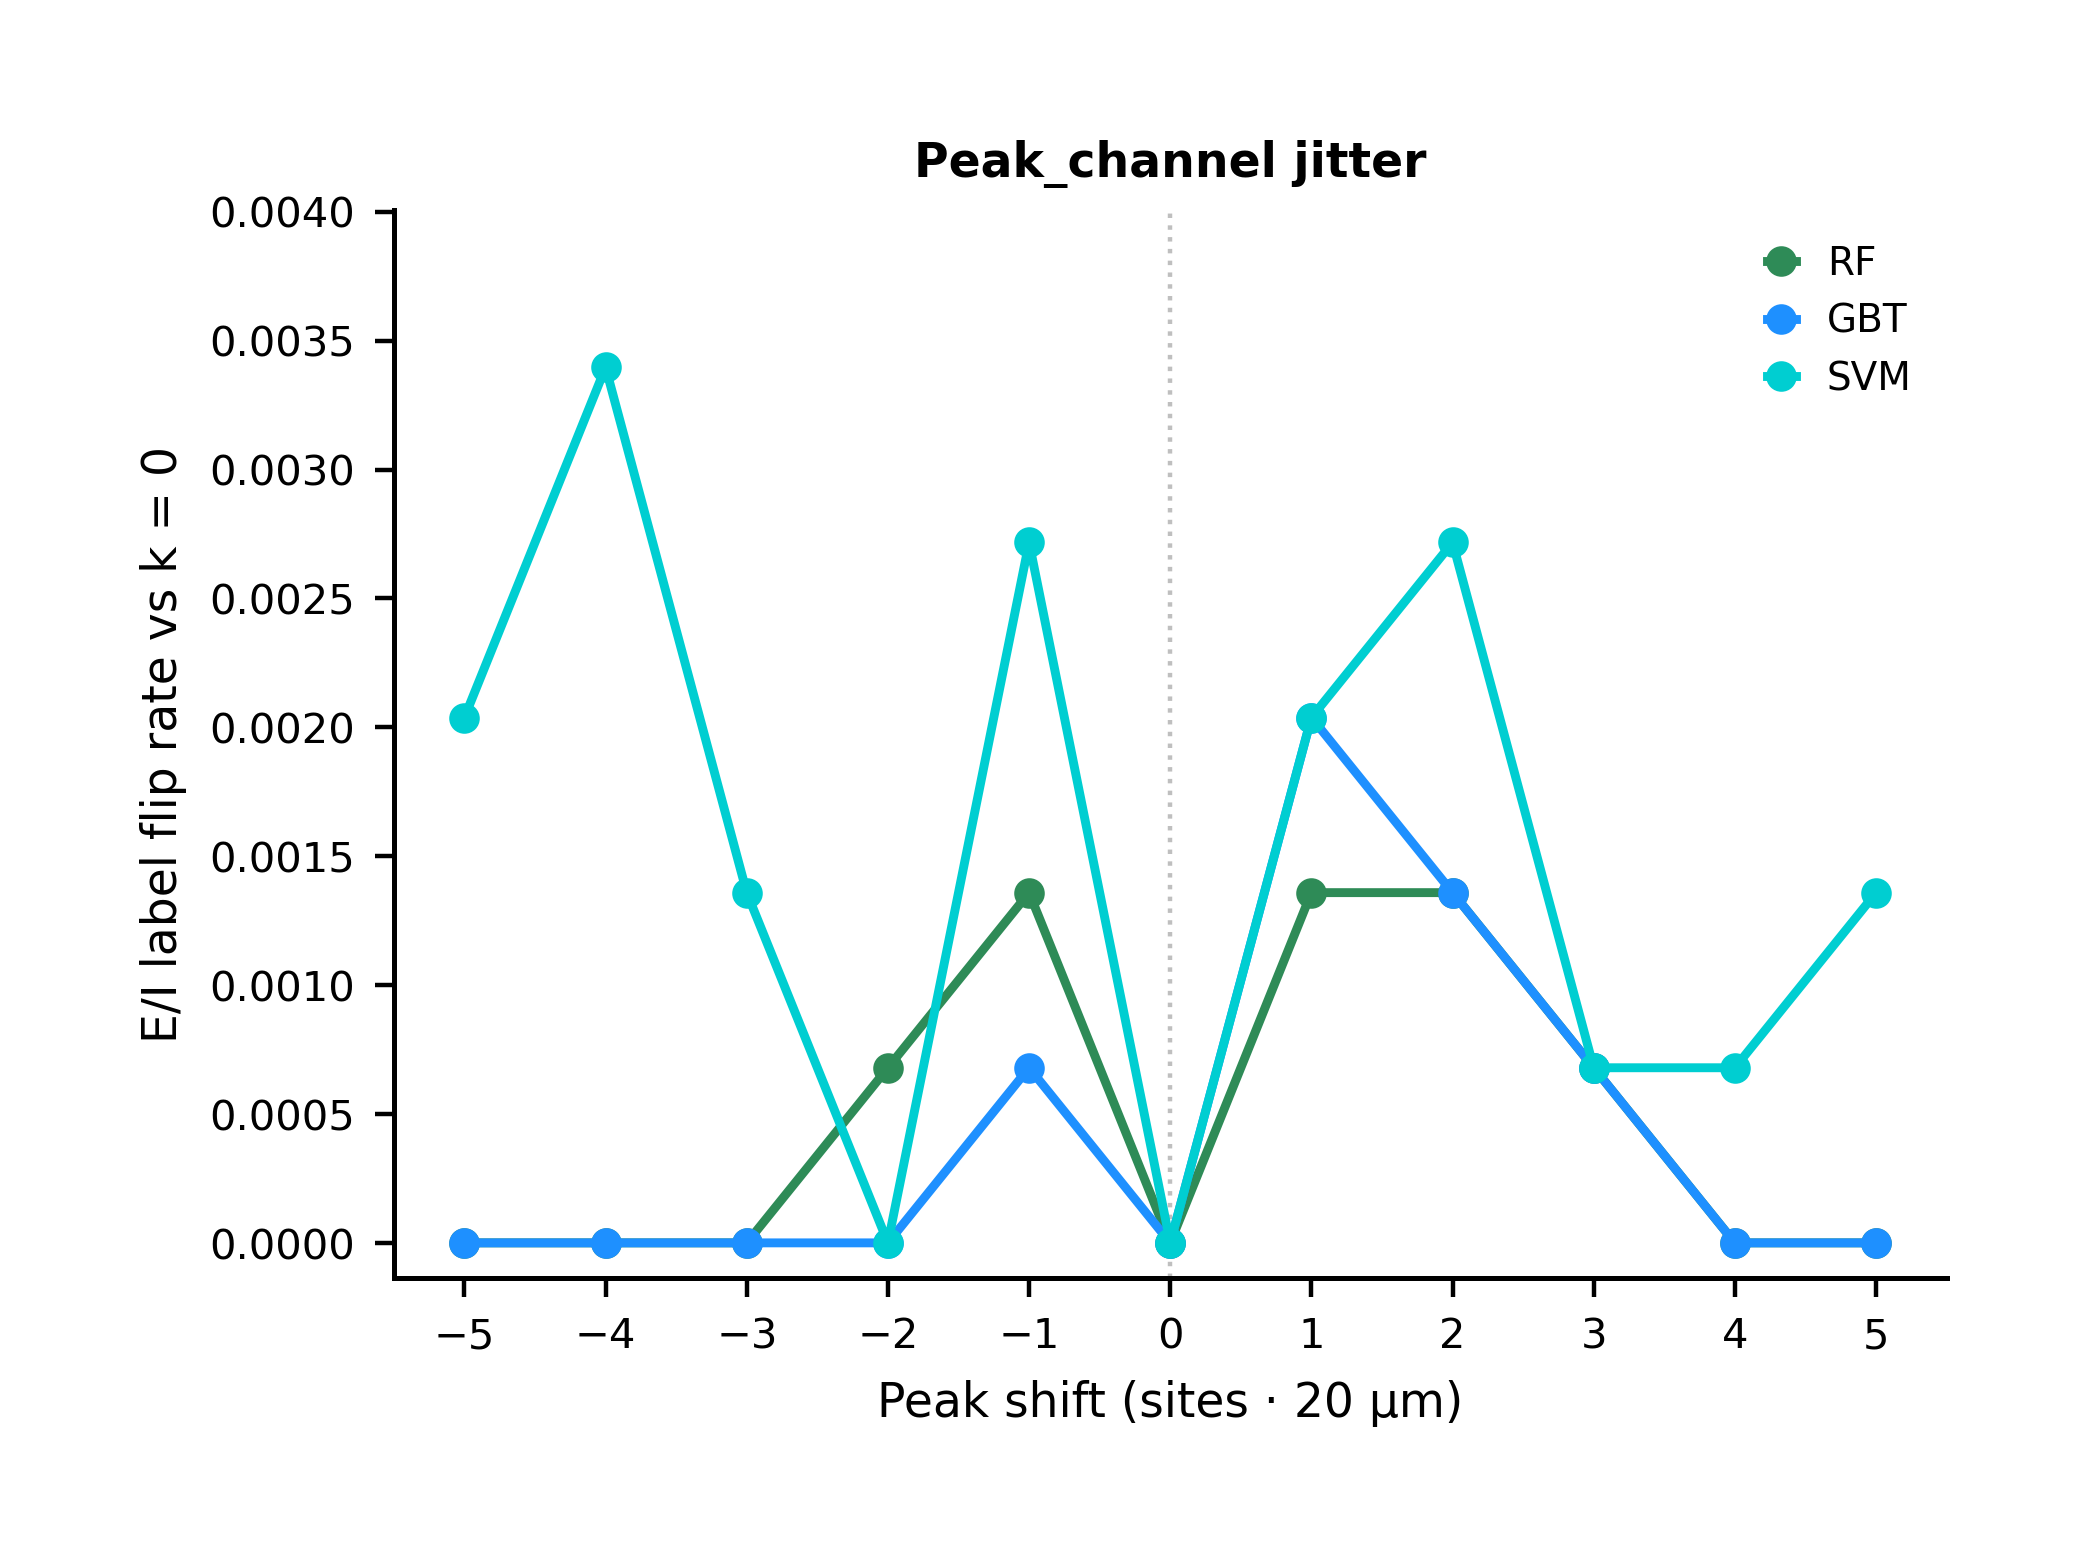

In [7]:
# --- Show the regenerated figures inline ---
from IPython.display import Image, Markdown, display

for f in ["fig_ablation.png",
          "fig_peak_jitter_type_flip_107.png", "fig_peak_jitter_type_flip_1603.png",
          "fig_peak_jitter_EI_flip_107.png", "fig_peak_jitter_EI_flip_1603.png"]:
    display(Markdown(f"**{f}**  (`{rel(OUT_DIR / f)}`)"))
    display(Image(filename=str(OUT_DIR / f), width=460))

In [8]:
# --- Consistency checks: figures vs pack JSON/CSV (FAIL loudly in the summary cell) ---

# 1) feature list / no A
for pack in PACKS:
    m = data[pack]["metrics"]
    check(f"{pack} includes_A is False", m["includes_A"] is False, str(m["includes_A"]))
    check(f"{pack} feature_cols == LOCKED_10", m["feature_cols"] == LOCKED_10, str(m["feature_cols"]))
    check(f"{pack} A not in features", "A" not in m["feature_cols"])

# 2) ablation bars match JSON (and expected ~values)
for algo in ALGOS:
    for key in ("all10", "single4", "multi6"):
        v = float(ABLATION[algo][key])
        exp = EXPECT_ABLATION[algo][key]
        check(f"ablation {algo}.{key} ~ {exp}", abs(v - exp) < 0.002, f"got {v:.6f}")

# 3) plotted series match CSV exactly (reload PNGs not needed — recompute series)
for pack in PACKS:
    df = data[pack]["curves"]
    check(f"{pack} CSV has 33 rows (3 algos × 11 k)", len(df) == 33, str(len(df)))
    check(f"{pack} k_sites cover -5..5", sorted(df.k_sites.unique().tolist()) == K_SITES)
    for algo in ALGOS:
        sub = df[df.algo == algo].sort_values("k_sites")
        # type_acc_all10 must equal type_acc_vs_vivo_label
        ok_eq = np.allclose(
            sub.type_acc_all10.to_numpy(float),
            sub.type_acc_vs_vivo_label.to_numpy(float),
            equal_nan=True,
        )
        check(f"{pack} {algo} type_acc_all10 == type_acc_vs_vivo_label", ok_eq)
        # k=0 flips must be 0
        r0 = sub[sub.k_sites == 0].iloc[0]
        check(f"{pack} {algo} type_flip@0 == 0", float(r0.type_flip_vs_k0) == 0.0, str(r0.type_flip_vs_k0))
        check(f"{pack} {algo} ei_flip@0 == 0", float(r0.ei_flip_vs_k0) == 0.0, str(r0.ei_flip_vs_k0))

# 4) RF k=±1 sanity (from signed-off numbers)
rf107 = data["noITL6_107"]["curves"]
rf107 = rf107[rf107.algo == "RF"].set_index("k_sites")
check("107 RF type_flip k=-1 ~ 18.7%", abs(float(rf107.loc[-1, "type_flip_vs_k0"]) - 0.186916) < 1e-5,
      f"{float(rf107.loc[-1, 'type_flip_vs_k0']):.6f}")
check("107 RF type_flip k=+1 ~ 15.0%", abs(float(rf107.loc[1, "type_flip_vs_k0"]) - 0.149533) < 1e-5,
      f"{float(rf107.loc[1, 'type_flip_vs_k0']):.6f}")

rf1603 = data["noITL6_1603"]["curves"]
rf1603 = rf1603[rf1603.algo == "RF"].set_index("k_sites")
check("1603 RF type_flip k=-1 ~ 0.61%", abs(float(rf1603.loc[-1, "type_flip_vs_k0"]) - 0.006114) < 1e-5,
      f"{float(rf1603.loc[-1, 'type_flip_vs_k0']):.6f}")
check("1603 RF type_flip k=+1 ~ 1.02%", abs(float(rf1603.loc[1, "type_flip_vs_k0"]) - 0.010190) < 1e-5,
      f"{float(rf1603.loc[1, 'type_flip_vs_k0']):.6f}")

# 5) titles (string constants used in this notebook)
TITLE_ABLATION = "Feature-set ablation on models"
TITLE_JITTER = "Peak_channel jitter"
check("ablation title exact", TITLE_ABLATION == "Feature-set ablation on models")
check("jitter title exact", TITLE_JITTER == "Peak_channel jitter")
check("no NeuroWAVE in titles", "NeuroWAVE" not in TITLE_ABLATION and "NeuroWAVE" not in TITLE_JITTER)
check("no (RF + GBT + SVM) in ablation title", "(RF + GBT + SVM)" not in TITLE_ABLATION)

# 6) output files exist
expected_files = [
    OUT_DIR / "fig_ablation.png",
    OUT_DIR / "fig_peak_jitter_type_flip_107.png",
    OUT_DIR / "fig_peak_jitter_type_flip_1603.png",
    OUT_DIR / "fig_peak_jitter_EI_flip_107.png",
    OUT_DIR / "fig_peak_jitter_EI_flip_1603.png",
]
for f in expected_files:
    check(f"exists {f.name}", f.is_file() and f.stat().st_size > 1000, f"size={f.stat().st_size if f.is_file() else 0}")

# 7) outputs are written only to OUT_DIR, never into the shipped data folders
for pack in PACKS:
    check(f"OUT_DIR is outside data/packs/{pack}", data[pack]["dir"].resolve() not in OUT_DIR.resolve().parents
          and data[pack]["dir"].resolve() != OUT_DIR.resolve())

[PASS] noITL6_107 includes_A is False — False
[PASS] noITL6_107 feature_cols == LOCKED_10 — ['W', 'TPW', 'Rslope', 'REP', 'spread', 'diff_spread', 'W_below', 'W_above', 'PL_below', 'PL_above']
[PASS] noITL6_107 A not in features
[PASS] noITL6_1603 includes_A is False — False
[PASS] noITL6_1603 feature_cols == LOCKED_10 — ['W', 'TPW', 'Rslope', 'REP', 'spread', 'diff_spread', 'W_below', 'W_above', 'PL_below', 'PL_above']
[PASS] noITL6_1603 A not in features
[PASS] ablation RF.all10 ~ 0.821 — got 0.820774
[PASS] ablation RF.single4 ~ 0.604 — got 0.603615
[PASS] ablation RF.multi6 ~ 0.784 — got 0.784114
[PASS] ablation GBT.all10 ~ 0.823 — got 0.823320
[PASS] ablation GBT.single4 ~ 0.573 — got 0.573320
[PASS] ablation GBT.multi6 ~ 0.777 — got 0.776731
[PASS] ablation SVM.all10 ~ 0.673 — got 0.672607
[PASS] ablation SVM.single4 ~ 0.434 — got 0.434063
[PASS] ablation SVM.multi6 ~ 0.54 — got 0.540224
[PASS] noITL6_107 CSV has 33 rows (3 algos × 11 k) — 33
[PASS] noITL6_107 k_sites cover -5..5

## Raw data audit (shipped `.npy`, vivo tables, models table)

The figures above come from the pack JSON/CSV. This section proves the shipped raw inputs are the ones the packs were built from:

1. **Integrity:** SHA-256 of every file listed in `MANIFEST_sha256.txt` matches.
2. **Small human (107):** `Patients_mean_EAP_small_human_107.npy` has shape $(108, 90, 21)$ = (units, time samples, channels). The pipeline drops unit index **36** (`BAD_UNIT=36`, `np.delete(arr, 36, axis=0)`) → $(107, 90, 21)$, which equals `mean_eap_geometry.shape` in the 107 `metrics_all.json` and the 107 rows of `vivo_small_human_107.csv`.
3. **Large human (1603):** `Patients_mean_EAP_large_human_1603.npy` has shape $(1603, 240, 21)$, row-aligned with the 1603 rows of `vivo_large_human_1603_merged.csv`. The pipeline keeps rows with all 10 locked features present (unlabeled units kept, ITL6 removed — none present) → **1472** rows (**1462** labeled), which equals `mean_eap_geometry.shape` $(1472, 240, 21)$ in the 1603 `metrics_all.json`.
4. **Models:** `EAP_models_normalized.csv` has 3947 simulated models; dropping ITL6 leaves **3928** (the ablation sample size).

Time axis: 107 stacks use $t=\mathrm{arange}(90)/30-0.6$ ms; 1603 stacks use 240 samples with the trough at sample 119.5 (`NW_PEAK_SAMPLE=119.5`). Sampling 30 kHz, 21 channels at 20 µm pitch, centre channel index 10.

In [9]:
# --- Raw data audit ---
def sha256(path: Path, chunk: int = 1 << 20) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(chunk), b""):
            h.update(block)
    return h.hexdigest().upper()

# 1) integrity vs manifest
manifest = BUNDLE_ROOT / "MANIFEST_sha256.txt"
check("MANIFEST_sha256.txt present", manifest.is_file())
for line in manifest.read_text(encoding="utf-8").splitlines():
    line = line.strip()
    if not line or line.startswith("#"):
        continue
    digest, relpath = line.split(None, 1)
    f = BUNDLE_ROOT / relpath
    check(f"sha256 {relpath}", f.is_file() and sha256(f) == digest.upper())

# 2) small human 107
BAD_UNIT_107 = 36
EAP_107 = EAP_DIR / "Patients_mean_EAP_small_human_107.npy"
eap107_raw = np.load(EAP_107)
check("107 raw npy shape == (108, 90, 21)", eap107_raw.shape == (108, 90, 21), str(eap107_raw.shape))
check("107 raw npy dtype float64 and finite", eap107_raw.dtype == np.float64 and np.isfinite(eap107_raw).all())
eap107 = np.delete(eap107_raw, BAD_UNIT_107, axis=0)
geo107 = data["noITL6_107"]["metrics"]["mean_eap_geometry"]
check("107 after drop unit 36 == metrics shape", list(eap107.shape) == geo107["shape"], f"{eap107.shape} vs {geo107['shape']}")
check("107 metrics bad_unit_dropped == 36", geo107["bad_unit_dropped"] == BAD_UNIT_107, str(geo107["bad_unit_dropped"]))
vivo107 = pd.read_csv(VIVO_DIR / "vivo_small_human_107.csv")
check("107 vivo rows == 107 == EAP units", len(vivo107) == eap107.shape[0] == 107, str(len(vivo107)))
check("107 vivo all labeled, no ITL6", vivo107.cell_type.notna().all() and not (vivo107.cell_type == "ITL6").any())
check("107 vivo has all locked features", all(c in vivo107.columns for c in LOCKED_10))

# 3) large human 1603 -> 1472
EAP_1603 = EAP_DIR / "Patients_mean_EAP_large_human_1603.npy"
eap1603_raw = np.load(EAP_1603, mmap_mode="r")
check("1603 raw npy shape == (1603, 240, 21)", eap1603_raw.shape == (1603, 240, 21), str(eap1603_raw.shape))
check("1603 raw npy dtype float64", eap1603_raw.dtype == np.float64)
vivo1603 = pd.read_csv(VIVO_DIR / "vivo_large_human_1603_merged.csv")
check("1603 vivo rows == EAP units (row-aligned)", len(vivo1603) == eap1603_raw.shape[0], str(len(vivo1603)))
keep = vivo1603[LOCKED_10].notna().all(axis=1) & ~vivo1603["cell_type"].isin(["ITL6"])
eap_rows_1472 = np.flatnonzero(keep.to_numpy())
eap1472 = np.asarray(eap1603_raw[eap_rows_1472])
geo1603 = data["noITL6_1603"]["metrics"]["mean_eap_geometry"]
check("1603 feature-complete subset == metrics shape", list(eap1472.shape) == geo1603["shape"], f"{eap1472.shape} vs {geo1603['shape']}")
n_lab = int(vivo1603.loc[keep, "cell_type"].notna().sum())
check("1603 subset labeled == 1462", n_lab == 1462, str(n_lab))
check("1603 subset finite", np.isfinite(eap1472).all())
check("1603 metrics bad_unit_dropped is None", geo1603["bad_unit_dropped"] is None, str(geo1603["bad_unit_dropped"]))

# geometry shared by both packs
for pack, geo in (("noITL6_107", geo107), ("noITL6_1603", geo1603)):
    check(f"{pack} geometry: 21 ch, centre 10, 20 um, k=-5..5",
          geo["shape"][2] == 21 and geo["center_channel"] == 10 and geo["pitch_um"] == 20.0 and geo["k_sites"] == K_SITES)

# 4) models
models = pd.read_csv(MODELS_CSV)
check("models rows == 3947", len(models) == 3947, str(len(models)))
n_models_noitl6 = int((models.cell_type != "ITL6").sum())
check("models without ITL6 == 3928", n_models_noitl6 == 3928, str(n_models_noitl6))
check("models have all locked features", all(c in models.columns for c in LOCKED_10))

[PASS] MANIFEST_sha256.txt present
[PASS] sha256 code/cell_figure_style.py
[PASS] sha256 data/eap/Patients_mean_EAP_large_human_1603.npy
[PASS] sha256 data/eap/Patients_mean_EAP_small_human_107.npy
[PASS] sha256 data/models/EAP_models_normalized.csv
[PASS] sha256 data/packs/noITL6_107/04_peak_jitter/metrics_all.json
[PASS] sha256 data/packs/noITL6_107/04_peak_jitter/peak_shift_curves.csv
[PASS] sha256 data/packs/noITL6_1603/04_peak_jitter/metrics_all.json
[PASS] sha256 data/packs/noITL6_1603/04_peak_jitter/peak_shift_curves.csv
[PASS] sha256 data/vivo/vivo_large_human_1603_merged.csv
[PASS] sha256 data/vivo/vivo_small_human_107.csv
[PASS] 107 raw npy shape == (108, 90, 21) — (108, 90, 21)
[PASS] 107 raw npy dtype float64 and finite
[PASS] 107 after drop unit 36 == metrics shape — (107, 90, 21) vs [107, 90, 21]
[PASS] 107 metrics bad_unit_dropped == 36 — 36
[PASS] 107 vivo rows == 107 == EAP units — 107
[PASS] 107 vivo all labeled, no ITL6
[PASS] 107 vivo has all locked features
[PASS] 

In [10]:
# --- Summary of all checks (figures + raw data) ---
n_pass = sum(1 for _, ok, _ in results if ok)
n_fail = sum(1 for _, ok, _ in results if not ok)
print("\n======== SUMMARY ========")
print(f"PASS={n_pass}  FAIL={n_fail}  TOTAL={len(results)}")
if n_fail:
    print("FAILED CHECKS:")
    for name, ok, detail in results:
        if not ok:
            print(" -", name, detail)
    raise AssertionError(f"{n_fail} consistency checks FAILED")
print("ALL CONSISTENCY CHECKS PASSED")


======== SUMMARY ========
PASS=82  FAIL=0  TOTAL=82
ALL CONSISTENCY CHECKS PASSED


## Optional RECOMPUTE (default OFF)

> **Warning.** `RECOMPUTE = True` re-runs the original analysis script `run_04_peak_jitter.py` (re-extract Wei features from the raw mean EAP, retrain hierarchical classifiers, re-score peak±k). This is slow and is **not** needed to reproduce the figures or to audit the inputs above.

What it needs:
- The original analysis code folder (`run_04_peak_jitter.py`, `common.py`, `hierarchical_multialgo.py`) and the NeuroWAVE package it imports. That code is **not** part of this bundle; point the environment variable `NW_CODE_ROOT` at it.
- `common.py` reads the simulated-models table through its `NW` constant (NeuroWAVE `RequiredFiles/EAP_models_normalized.csv`). Point it at `data/models/EAP_models_normalized.csv` from this bundle, or at your own NeuroWAVE checkout.
- Data: the raw `.npy`, vivo tables and models table shipped in `data/` (passed via the same `NW_*` environment variables the packs used).

Output goes to `recompute_out/<pack>/` inside the bundle; it does not touch `data/`.

In [11]:
# --- Optional RECOMPUTE (skipped unless RECOMPUTE=True) ---
RECOMPUTE_PACK = "noITL6_107"  # or "noITL6_1603"

PACK_ENV = {  # same NW_* settings the packs were built with, pointed at bundle data
    "noITL6_107": {
        "NW_PACK_NAME": "noITL6_107", "NW_DROP_TYPES": "ITL6",
        "NW_MEAN_EAP": str(EAP_DIR / "Patients_mean_EAP_small_human_107.npy"),
        "NW_VIVO_CSV": str(VIVO_DIR / "vivo_small_human_107.csv"),
        "NW_BAD_UNIT": "36", "NW_KEEP_UNLABELED_VIVO": "0", "NW_FORCE_ABLATION": "1",
        "NW_EXPECT_N_MODELS": "3928", "NW_EXPECT_N_VIVO": "107", "NW_PEAK_SAMPLE": "",
    },
    "noITL6_1603": {
        "NW_PACK_NAME": "noITL6_1603", "NW_DROP_TYPES": "ITL6",
        "NW_MEAN_EAP": str(EAP_DIR / "Patients_mean_EAP_large_human_1603.npy"),
        "NW_VIVO_CSV": str(VIVO_DIR / "vivo_large_human_1603_merged.csv"),
        "NW_BAD_UNIT": "", "NW_KEEP_UNLABELED_VIVO": "1", "NW_FORCE_ABLATION": "1",
        "NW_EXPECT_N_MODELS": "3928", "NW_EXPECT_N_VIVO": "1472", "NW_PEAK_SAMPLE": "119.5",
    },
}

if not RECOMPUTE:
    print("RECOMPUTE=False — skipping re-run of run_04_peak_jitter.py (figures built from shipped pack JSON/CSV;")
    print("raw .npy / vivo / models inputs verified in the Raw data audit section).")
else:
    import runpy
    code_root = os.environ.get("NW_CODE_ROOT", "").strip()
    if not code_root or not (Path(code_root) / "run_04_peak_jitter.py").is_file():
        raise RuntimeError("RECOMPUTE=True needs NW_CODE_ROOT pointing at the folder with run_04_peak_jitter.py / common.py")
    out = BUNDLE_ROOT / "recompute_out" / RECOMPUTE_PACK
    out.mkdir(parents=True, exist_ok=True)
    os.environ.update(PACK_ENV[RECOMPUTE_PACK])
    os.environ["NW_ANALYSIS_OUT"] = str(out)
    if RECOMPUTE_PACK == "noITL6_1603":
        os.environ["NW_VIVO_GAMMA_CSV"] = str(out / "_no_gamma.csv")  # gamma disabled for 1603, as in the pack
    sys.path.insert(0, code_root)
    print("RECOMPUTE=True — running run_04_peak_jitter.py for", RECOMPUTE_PACK, "->", rel(out))
    runpy.run_path(str(Path(code_root) / "run_04_peak_jitter.py"), run_name="__main__")

RECOMPUTE=False — skipping re-run of run_04_peak_jitter.py (figures built from shipped pack JSON/CSV;
raw .npy / vivo / models inputs verified in the Raw data audit section).


## Provenance notes (for supervisor / LLM audit)

| Item | Value |
|------|-------|
| Sim models for ablation | **3928** after dropping ITL6 from 3947 |
| Ablation metric | Stratified 5-fold **type** accuracy (hierarchical RF/GBT/SVM) |
| Features | Locked **10**, **`includes_A=False`** |
| Pack 107 vivo EAP shape | `(107, 90, 21)` = shipped `(108, 90, 21)` with unit index 36 dropped (`BAD_UNIT=36`) |
| Pack 1603 vivo EAP shape | `(1472, 240, 21)` = feature-complete rows of shipped `(1603, 240, 21)`; labels from merged dataframe `cell_type` (**1462 labeled / 1472** rows — accuracy uses labeled subset; flips use all scored units) |
| Ablation identical across packs | Yes (models-only) |
| Raw EAP shipped? | **Yes**: `data/eap/Patients_mean_EAP_small_human_107.npy` (108×90×21, 1.6 MB) and `data/eap/Patients_mean_EAP_large_human_1603.npy` (1603×240×21, 64.6 MB); verified in *Raw data audit* |
| Raw EAP needed to draw the figures? | No — figures use pack JSON/CSV; raw EAP is for audit / `RECOMPUTE=True` |
| Output directory | `nw_notebook_out/` inside the bundle (relative path; shipped `data/` is never written) |
| Paths | All relative to the bundle folder (`NW_BUNDLE_ROOT` override); no drive letters or user folders |

Titles used (centered, no NeuroWAVE / noITL6 / no algorithm list in the title string):

- Ablation: `Feature-set ablation on models`
- Type-flip & E/I: `Peak_channel jitter`